In [55]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/AnjaliBhoi/Prompt-Based-Multimodal-Meme-Classification-using-Image-Captioning.git
%cd Prompt-Based-Multimodal-Meme-Classification-using-Image-Captioning

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'Prompt-Based-Multimodal-Meme-Classification-using-Image-Captioning'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 2.83 MiB | 35.29 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/Prompt-Based-Multimodal-Meme-Classification-using-Image-Captioning/Prompt-Based-Multimodal-Meme-Classification-using-Image-Captioning


In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [58]:
#load data
CSV_PATH = "/content/drive/MyDrive/Multimodal/Cyberbully_corrected_emotion_sentiment.csv"
IMG_DIR  = "/content/drive/MyDrive/Multimodal/bully_data/"

In [59]:
# Check both paths actually exist
print(f"CSV exists   : {os.path.exists(CSV_PATH)}")
print(f"IMG exists   : {os.path.exists(IMG_DIR)}")

# Count images
images = os.listdir(IMG_DIR)
print(f"Images found : {len(images)}")
print(f"Sample names : {images[:5]}")

CSV exists   : True
IMG exists   : True
Images found : 5999
Sample names : ['5834.jpg', '4020.jpg', '5853.jpg', '5954.jpg', '3735.jpg']


In [60]:
df_raw = pd.read_csv(CSV_PATH)

print(f"Shape : {df_raw.shape}  →  {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_raw[["Img-Name", "Img-Text", "Img-Label", "Sentiment", "Emotion", "Sarcasm"]].head(3)

Shape : (5865, 24)  →  5865 rows, 24 columns

First 3 rows:


,Img-Name,Img-Text,Img-Label,Sentiment,Emotion,Sarcasm
0,0.jpg,Shivam @shivamishraa Girls be named naina and ...,Nonbully,Negative,Disgust,Yes
1,1.jpg,Aaloo ke paranthe is the best breakfast Omelet...,Nonbully,Neutral,Other,No
2,2.jpg,For Boyfriend For Bestfriend DESI ADUKT TROLLS,Bully,Negative,Ridicule,No


In [61]:
KEEP_COLUMNS = [
    "Img-Name",          # image filename
    "Img-Text",          # meme text (main input)
    "Img-Label",         # overall label → Task 1 target
    "Img-Text-Label",    # text-only label → useful for ablation
    "Text-Label",        # another text-only label → useful for ablation
    "Sentiment",         # sentiment → Task 2 target
    "Emotion",           # emotion type → useful for analysis
    "Sarcasm",           # sarcasm flag → useful for analysis
    "Harmful-Score",     # harm level → useful for error analysis
    "Target",            # who is targeted → useful for analysis
    "Doubtful",          # uncertain labels → handle carefully
]

df = df_raw[KEEP_COLUMNS].copy()

print("=== COLUMNS KEPT ===")
for col in df.columns:
    non_null = df[col].dropna()
    print(f"  {col:20s} → {non_null.nunique()} unique values: {non_null.unique()[:4]}")

=== COLUMNS KEPT ===
  Img-Name             → 5863 unique values: ['0.jpg' '1.jpg' '2.jpg' '3.jpg']
  Img-Text             → 5730 unique values: ["Shivam @shivamishraa Girls be named naina and then have eyes that don't work"
 'Aaloo ke paranthe is the best breakfast Omelette is the best breakfast BONK Paranthe Omelette Poha'
 'For Boyfriend For Bestfriend DESI ADUKT TROLLS'
 "You find a new YouTuber He's funny All of his videos are funny His last video was 4 years ago"]
  Img-Label            → 2 unique values: ['Nonbully' 'Bully']
  Img-Text-Label       → 2 unique values: ['Bully' 'Nonbully']
  Text-Label           → 2 unique values: ['Bully' 'Nonbully']
  Sentiment            → 3 unique values: ['Negative' 'Neutral' 'Positive']
  Emotion              → 10 unique values: ['Disgust' 'Other' 'Ridicule' 'Sadness']
  Sarcasm              → 2 unique values: ['Yes' 'No']
  Harmful-Score        → 3 unique values: ['Partially-Harmful' 'Harmless' 'Very-Harmful']
  Target               → 4 uniq

In [62]:
# Check missing values before dropping
print("=== MISSING VALUES BEFORE CLEANING ===")
print(df.isna().sum())

# Drop rows where essential columns are missing
# Essential = we absolutely need these to run the model
ESSENTIAL = ["Img-Name", "Img-Text", "Img-Label", "Sentiment"]
df = df.dropna(subset=ESSENTIAL)
df = df.reset_index(drop=True)

print(f"\n=== AFTER DROPPING MISSING ESSENTIAL VALUES ===")
print(f"Rows remaining : {len(df)}")
print(f"Rows dropped   : {5865 - len(df)}")
print(f"\nRemaining missing values (non-essential columns):")
print(df.isna().sum())

# Note about Doubtful column
print(f"\nDoubtful column breakdown:")
print(df["Doubtful"].value_counts(dropna=False))

=== MISSING VALUES BEFORE CLEANING ===
Img-Name             2
Img-Text             2
Img-Label           11
Img-Text-Label      11
Text-Label          11
Sentiment           11
Emotion             11
Sarcasm             11
Harmful-Score       12
Target            2760
Doubtful          5862
dtype: int64

=== AFTER DROPPING MISSING ESSENTIAL VALUES ===
Rows remaining : 5854
Rows dropped   : 11

Remaining missing values (non-essential columns):
Img-Name             0
Img-Text             0
Img-Label            0
Img-Text-Label       0
Text-Label           0
Sentiment            0
Emotion              0
Sarcasm              0
Harmful-Score        1
Target            2749
Doubtful          5853
dtype: int64

Doubtful column breakdown:
Doubtful
NaN      5853
doubt       1
Name: count, dtype: int64


In [63]:
# Build full image path for each row
df["image_path"] = df["Img-Name"].apply(lambda x: os.path.join(IMG_DIR, str(x)))

# Check which images exist on disk
df["image_exists"] = df["image_path"].apply(os.path.exists)

print(f"Total rows          : {len(df)}")
print(f"Images found        : {df['image_exists'].sum()}")
print(f"Images NOT found    : {(~df['image_exists']).sum()}")

# Show which ones are missing
missing = df[~df["image_exists"]][["Img-Name"]]
if len(missing) > 0:
    print(f"\nMissing files:")
    print(missing)

# Keep only rows where the image exists
df = df[df["image_exists"]].drop(columns=["image_exists"])
df = df.reset_index(drop=True)

print(f"\nFinal usable rows: {len(df)}")

Total rows          : 5854
Images found        : 5846
Images NOT found    : 8

Missing files:
      Img-Name
2        2.jpg
81      81.jpg
85      85.jpg
110    110.png
135    135.jpg
176    177.jpg
2634  2644.jpg
5479  5631.jpg

Final usable rows: 5846


In [64]:
# Task 1: Cyberbullying  →  Bully=1, Nonbully=0
df["bully_label"] = df["Img-Label"].map({"Bully": 1, "Nonbully": 0})

# Task 2: Sentiment  →  Negative=0, Neutral=1, Positive=2
df["sentiment_label"] = df["Sentiment"].map({"Negative": 0, "Neutral": 1, "Positive": 2})

# Extra: encode Img-Text-Label and Text-Label too (useful for ablation later)
df["text_bully_label"] = df["Img-Text-Label"].map({"Bully": 1, "Nonbully": 0})
df["text_only_label"]  = df["Text-Label"].map({"Bully": 1, "Nonbully": 0})

# Extra: encode Sarcasm as binary
df["sarcasm_binary"] = df["Sarcasm"].map({"Yes": 1, "No": 0})

print("=== LABEL ENCODING ===")

print("\nTask 1 — Cyberbullying (Img-Label):")
print(df["bully_label"].value_counts().rename({1: "Bully (1)", 0: "Not-Bully (0)"}))

print("\nTask 2 — Sentiment:")
print(df["sentiment_label"].value_counts().rename({
    0: "Negative (0)", 1: "Neutral (1)", 2: "Positive (2)"
}))

print("\nText-only label (for ablation):")
print(df["text_bully_label"].value_counts().rename({1: "Bully (1)", 0: "Not-Bully (0)"}))

print("\nSarcasm binary:")
print(df["sarcasm_binary"].value_counts().rename({1: "Sarcastic (1)", 0: "Not Sarcastic (0)"}))

# Preview all columns
print(f"\nFull dataframe shape: {df.shape}")
df.head(3)

=== LABEL ENCODING ===

Task 1 — Cyberbullying (Img-Label):
bully_label
Not-Bully (0)    5045
Bully (1)         801
Name: count, dtype: int64

Task 2 — Sentiment:
sentiment_label
Negative (0)    2680
Neutral (1)     2559
Positive (2)     607
Name: count, dtype: int64

Text-only label (for ablation):
text_bully_label
Bully (1)        3214
Not-Bully (0)    2632
Name: count, dtype: int64

Sarcasm binary:
sarcasm_binary
Not Sarcastic (0)    3672
Sarcastic (1)        2174
Name: count, dtype: int64

Full dataframe shape: (5846, 17)


,Img-Name,Img-Text,Img-Label,Img-Text-Label,Text-Label,Sentiment,Emotion,Sarcasm,Harmful-Score,Target,Doubtful,image_path,bully_label,sentiment_label,text_bully_label,text_only_label,sarcasm_binary
0,0.jpg,Shivam @shivamishraa Girls be named naina and ...,Nonbully,Bully,Bully,Negative,Disgust,Yes,Partially-Harmful,Individual,NaN,/content/drive/MyDrive/Multimodal/bully_data/0...,0,0,1,1,1
1,1.jpg,Aaloo ke paranthe is the best breakfast Omelet...,Nonbully,Nonbully,Nonbully,Neutral,Other,No,Harmless,NaN,NaN,/content/drive/MyDrive/Multimodal/bully_data/1...,0,1,0,0,0
2,3.jpg,You find a new YouTuber He's funny All of his ...,Nonbully,Nonbully,Nonbully,Neutral,Sadness,No,Harmless,NaN,NaN,/content/drive/MyDrive/Multimodal/bully_data/3...,0,1,0,0,0


In [65]:
print(f"Total usable memes : {len(df)}")

print("\nTask 1 — Cyberbullying:")
for label, count in df["Img-Label"].value_counts().items():
    print(f"  {label:10s}: {count:5d}  ({count/len(df)*100:.1f}%)")

print("\nTask 2 — Sentiment:")
for label, count in df["Sentiment"].value_counts().items():
    print(f"  {label:10s}: {count:5d}  ({count/len(df)*100:.1f}%)")


Total usable memes : 5846

Task 1 — Cyberbullying:
  Nonbully  :  5045  (86.3%)
  Bully     :   801  (13.7%)

Task 2 — Sentiment:
  Negative  :  2680  (45.8%)
  Neutral   :  2559  (43.8%)
  Positive  :   607  (10.4%)


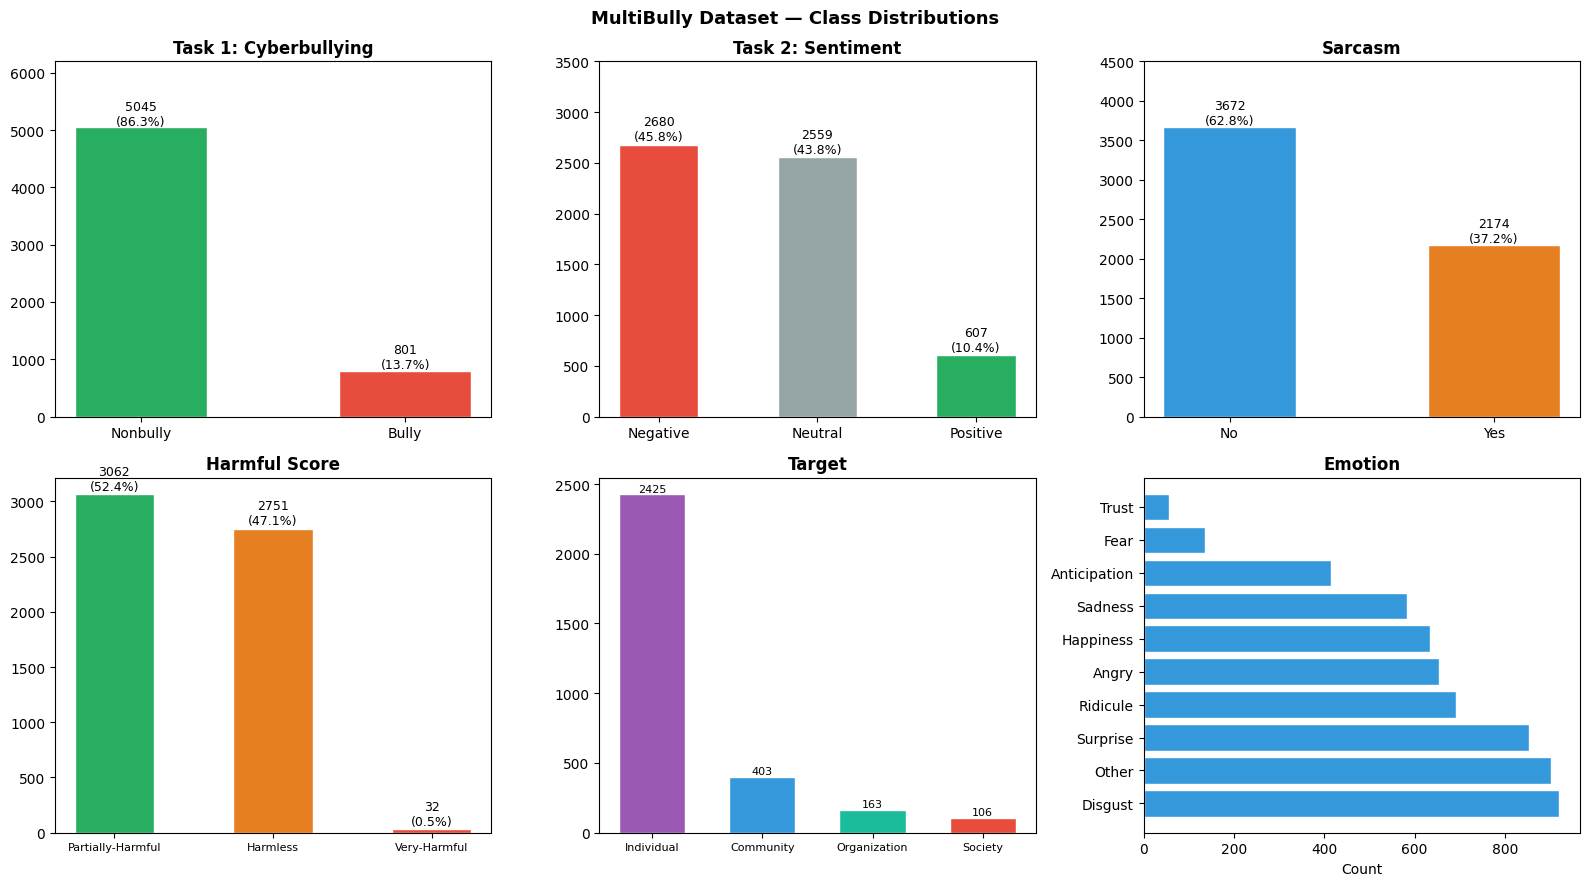

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("MultiBully Dataset — Class Distributions", fontsize=13, fontweight="bold")

# Cyberbullying
bully_counts = df["Img-Label"].value_counts()
axes[0][0].bar(bully_counts.index, bully_counts.values,
               color=["#27AE60", "#E74C3C"], edgecolor="white", width=0.5)
axes[0][0].set_title("Task 1: Cyberbullying", fontweight="bold")
for i, v in enumerate(bully_counts.values):
    axes[0][0].text(i, v + 40, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
axes[0][0].set_ylim(0, 6200)

# Sentiment
sent_counts = df["Sentiment"].value_counts()
axes[0][1].bar(sent_counts.index, sent_counts.values,
               color=["#E74C3C", "#95A5A6", "#27AE60"], edgecolor="white", width=0.5)
axes[0][1].set_title("Task 2: Sentiment", fontweight="bold")
for i, v in enumerate(sent_counts.values):
    axes[0][1].text(i, v + 40, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
axes[0][1].set_ylim(0, 3500)

# Sarcasm
sarc_counts = df["Sarcasm"].value_counts()
axes[0][2].bar(sarc_counts.index, sarc_counts.values,
               color=["#3498DB", "#E67E22"], edgecolor="white", width=0.5)
axes[0][2].set_title("Sarcasm", fontweight="bold")
for i, v in enumerate(sarc_counts.values):
    axes[0][2].text(i, v + 40, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
axes[0][2].set_ylim(0, 4500)

# Harmful Score
harm_counts = df["Harmful-Score"].value_counts()
axes[1][0].bar(harm_counts.index, harm_counts.values,
               color=["#27AE60", "#E67E22", "#E74C3C"], edgecolor="white", width=0.5)
axes[1][0].set_title("Harmful Score", fontweight="bold")
for i, v in enumerate(harm_counts.values):
    axes[1][0].text(i, v + 40, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
axes[1][0].tick_params(axis='x', labelsize=8)

# Target
target_counts = df["Target"].value_counts()
axes[1][1].bar(target_counts.index, target_counts.values,
               color=["#9B59B6","#3498DB","#1ABC9C","#E74C3C","#E67E22"],
               edgecolor="white", width=0.6)
axes[1][1].set_title("Target", fontweight="bold")
for i, v in enumerate(target_counts.values):
    axes[1][1].text(i, v + 20, f"{v}", ha="center", fontsize=8)
axes[1][1].tick_params(axis='x', labelsize=8)

# Emotion
emotion_counts = df["Emotion"].value_counts()
axes[1][2].barh(emotion_counts.index, emotion_counts.values,
                color="#3498DB", edgecolor="white")
axes[1][2].set_title("Emotion", fontweight="bold")
axes[1][2].set_xlabel("Count")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [67]:
# Check for duplicate image names
dup_images = df[df["Img-Name"].duplicated(keep=False)]
print(f"Duplicate image names : {len(dup_images)}")

# Check for duplicate text
dup_text = df[df["Img-Text"].duplicated(keep=False)]
print(f"Duplicate meme texts  : {len(dup_text)}")

if len(dup_text) > 0:
    print("\nSample duplicate texts:")
    print(dup_text[["Img-Name", "Img-Text", "Img-Label"]].head(6).to_string())
else:
    print("\nNo duplicate texts found ✓")

Duplicate image names : 0
Duplicate meme texts  : 253

Sample duplicate texts:
    Img-Name                                                                                                                       Img-Text Img-Label
17    18.png                                                                                      when you catch your goat with another man  Nonbully
21    22.png                                                             do you think a terrorist has or could infiltrate our goverment ???  Nonbully
36    37.jpg                                                                    12 year old me being ready the night before the School trip  Nonbully
49    50.png                                                                     i don't always fuck midgets but when i do, i go balls deep  Nonbully
78    79.jpg  Aap muskura kyun rhe hai?Pay attention to the class..Mere baare me itna mat socho Attendance k liye aata hu Padhai k liye nhi  Nonbully
108  112.png         

In [68]:
def check_image_quality(image_path):
    try:
        img = Image.open(image_path).convert("RGB")
        w, h = img.size
        if w < 50 or h < 50:
            return "too_small"
        elif w * h < 10000:
            return "very_low_res"
        else:
            return "ok"
    except:
        return "corrupted"

print("Checking image quality... (may take a minute)")
df["img_quality"] = df["image_path"].apply(check_image_quality)

print("\n=== IMAGE QUALITY CHECK ===")
print(df["img_quality"].value_counts())

bad = df[df["img_quality"] != "ok"]
print(f"\nProblematic images: {len(bad)}")
if len(bad) > 0:
    print(bad[["Img-Name", "img_quality"]].to_string())
else:
    print("All images look good ✓")

Checking image quality... (may take a minute)

=== IMAGE QUALITY CHECK ===
img_quality
ok           5793
corrupted      53
Name: count, dtype: int64

Problematic images: 53
      Img-Name img_quality
404    411.jpg   corrupted
677    685.jpg   corrupted
683    691.jpg   corrupted
815    823.jpg   corrupted
1288  1297.jpg   corrupted
1360  1369.jpg   corrupted
1364  1373.jpg   corrupted
1368  1377.jpg   corrupted
1384  1393.jpg   corrupted
1600  1609.jpg   corrupted
1610  1619.jpg   corrupted
1634  1643.jpg   corrupted
1636  1645.jpg   corrupted
2351  2362.jpg   corrupted
2355  2366.jpg   corrupted
2381  2392.jpg   corrupted
2638  2655.jpg   corrupted
2646  2663.jpg   corrupted
2648  2665.jpg   corrupted
2687  2705.jpg   corrupted
2689  2707.jpg   corrupted
2705  2723.jpg   corrupted
2777  2795.jpg   corrupted
2853  2874.jpg   corrupted
2984  3010.jpg   corrupted
2988  3014.jpg   corrupted
2998  3024.jpg   corrupted
3002  3028.jpg   corrupted
3248  3275.jpg   corrupted
3255  3283.jpg   

In [69]:
#Remove corrupted images
print(f"Before removing corrupted: {len(df)} rows")

# Remove corrupted images
df = df[df["img_quality"] == "ok"].reset_index(drop=True)

print(f"After removing corrupted : {len(df)} rows")
print(f"Removed                  : 53 corrupted images")
print(f"\nAll remaining images are good quality ✓")

Before removing corrupted: 5846 rows
After removing corrupted : 5793 rows
Removed                  : 53 corrupted images

All remaining images are good quality ✓


In [70]:
BULLY_KEYWORDS = [
    "loser", "ugly", "stupid", "idiot", "hate",
    "dumb", "fat", "useless", "worthless", "moron",
    "bakwas", "bewakoof", "gadha"
]

def quick_label_check(row):
    text  = str(row["Img-Text"]).lower()
    label = row["Img-Label"]
    has_bully_word = any(word in text for word in BULLY_KEYWORDS)

    if label == "Bully" and has_bully_word:
        return "consistent"
    elif label == "Nonbully" and not has_bully_word:
        return "consistent"
    elif label == "Bully" and not has_bully_word:
        return "check — bully but no keywords"
    else:
        return "check — has keywords but nonbully"

df["label_check"] = df.apply(quick_label_check, axis=1)

print("=== LABEL CONSISTENCY CHECK ===")
print(df["label_check"].value_counts())
print("\nNote: flagged rows are not necessarily wrong —")
print("cyberbullying is often sarcastic, so keywords may not appear directly.")

flagged = df[df["label_check"].str.startswith("check")]
print(f"\nTotal flagged: {len(flagged)}")
print("\nSample flagged rows:")
print(flagged[["Img-Name","Img-Text","Img-Label"]].head(5).to_string())

=== LABEL CONSISTENCY CHECK ===
label_check
consistent                           4896
check — bully but no keywords         776
check — has keywords but nonbully     121
Name: count, dtype: int64

Note: flagged rows are not necessarily wrong —
cyberbullying is often sarcastic, so keywords may not appear directly.

Total flagged: 897

Sample flagged rows:
   Img-Name                                                                  Img-Text Img-Label
4     5.jpg                                         what if we use 100% of our brain?     Bully
8     9.jpg          zaheer khan invented knukle bowl lord shardhul with fu@kle bowl-     Bully
10   11.jpg  ADDING MEDIEVAL WEAPONS TO DOGS PLAYING ON BEACH NEEDS TO BECOME A THING     Bully
15   16.png                       im long and strong and down to get the goat hump on     Bully
18   19.jpg                              my insta stories my real life SCOOPWHOOP.com     Bully


In [71]:
SEED = 42
N_PER_CLASS = 4

bully_sample     = df[df["bully_label"] == 1].sample(N_PER_CLASS, random_state=SEED)
not_bully_sample = df[df["bully_label"] == 0].sample(N_PER_CLASS, random_state=SEED)
sample = pd.concat([bully_sample, not_bully_sample]).reset_index(drop=True)

print("=== STRATIFIED RANDOM SAMPLE ===")
print(f"Picking {N_PER_CLASS} bully + {N_PER_CLASS} not-bully  |  seed = {SEED}\n")

for _, row in sample.iterrows():
    label = "BULLY" if row["bully_label"] == 1 else "NOT BULLY"
    print(f"[{label:10s}] {str(row['Img-Name']):10s} | "
          f"Sentiment: {row['Sentiment']:8s} | "
          f"Text: {str(row['Img-Text'])[:55]}...")

=== STRATIFIED RANDOM SAMPLE ===
Picking 4 bully + 4 not-bully  |  seed = 42

[BULLY     ] 5685.jpg   | Sentiment: Negative | Text: Lalit Rajput @trollerbiyLalit When your mix water with ...
[BULLY     ] 5616.jpg   | Sentiment: Negative | Text: Unit 11 Making the right choices Sorry I have one *Teac...
[BULLY     ] 1975.jpg   | Sentiment: Neutral  | Text: My dream when my bestfriend get married...
[BULLY     ] 4622.jpg   | Sentiment: Negative | Text: let me in! nidhi razdan with her fake application outsi...
[NOT BULLY ] 99.jpg     | Sentiment: Negative | Text: teacher *I hope you guys have understood todays topic *...
[NOT BULLY ] 2720.jpg   | Sentiment: Negative | Text: Kareena aged 10 had attended SAIF'S marriage with amrit...
[NOT BULLY ] 3174.jpg   | Sentiment: Negative | Text: Breaking News GF ke sath nazar aaye Taimur 19:35 Saif b...
[NOT BULLY ] 5990.jpg   | Sentiment: Negative | Text: From sab milke plan banate hai To sab milne ka plan ban...


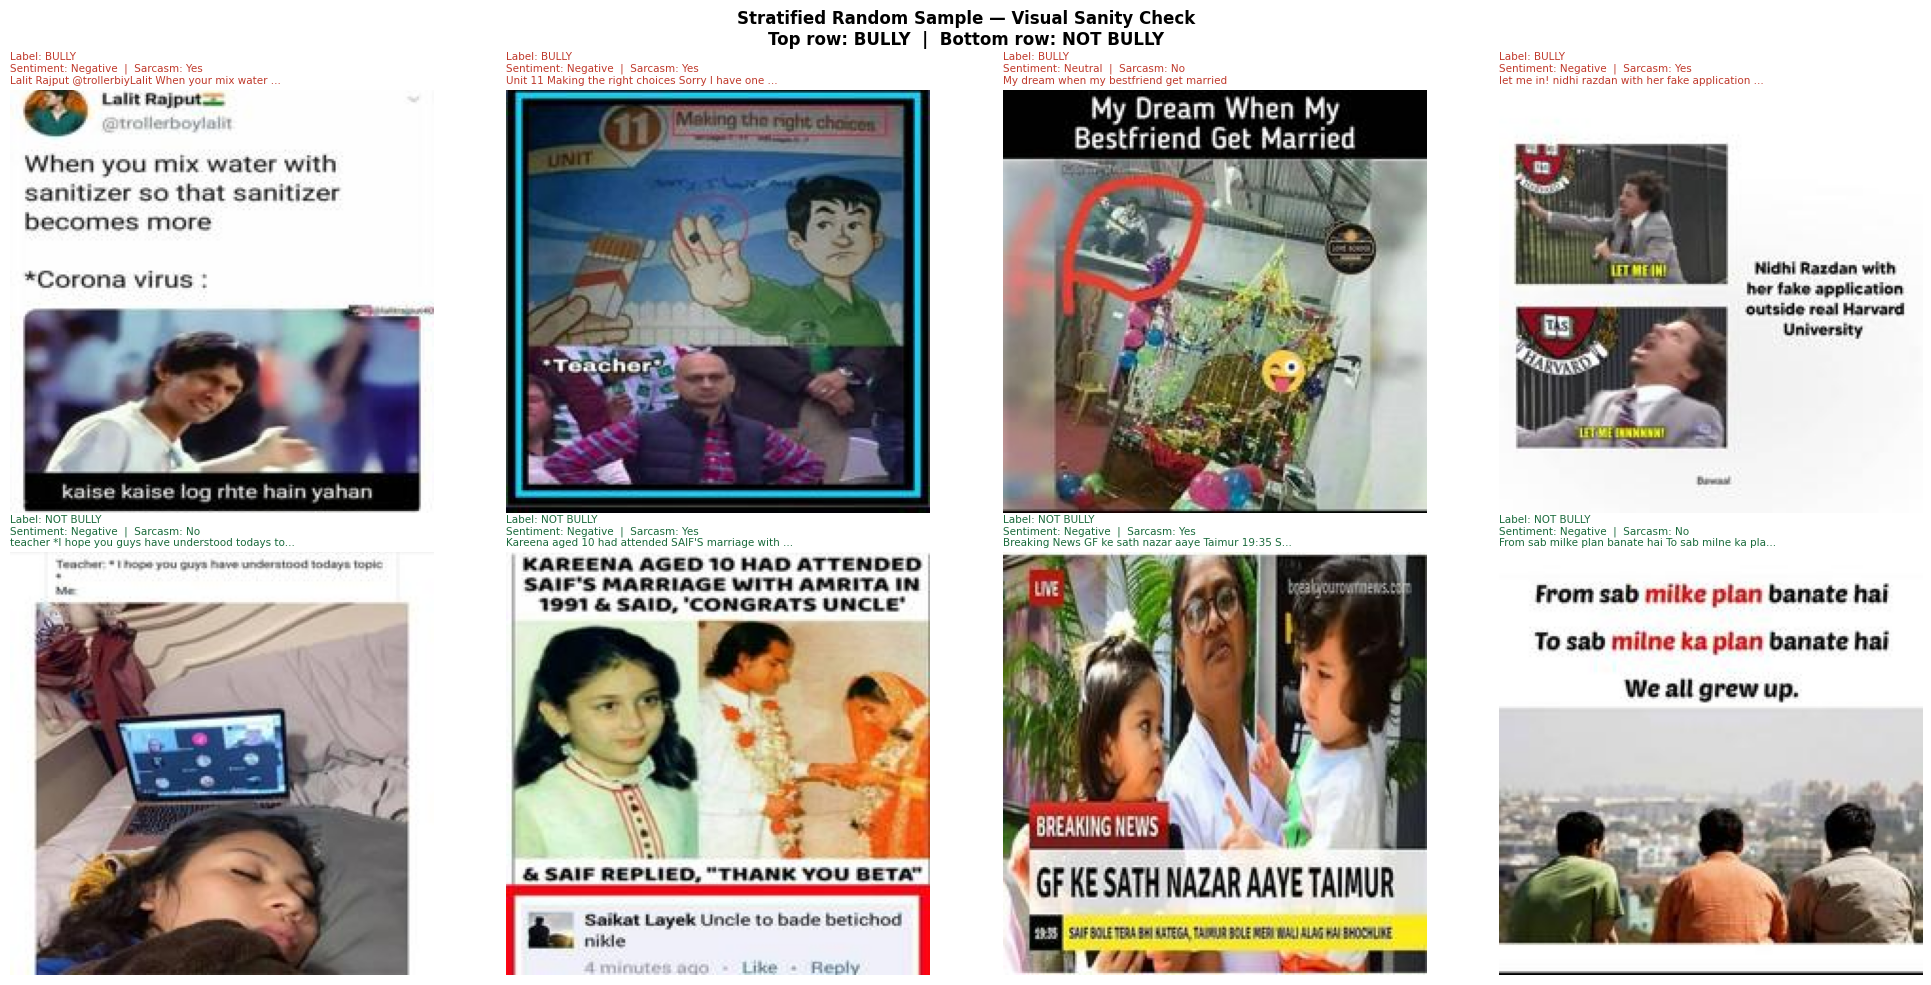

Saved: sanity_check.png


In [72]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    "Stratified Random Sample — Visual Sanity Check\n"
    "Top row: BULLY  |  Bottom row: NOT BULLY",
    fontsize=12, fontweight="bold"
)

for i, (_, row) in enumerate(sample.iterrows()):
    r, c = divmod(i, N_PER_CLASS)
    ax = axes[r][c]

    try:
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, "Error loading image",
                ha="center", va="center", transform=ax.transAxes)

    is_bully  = row["bully_label"] == 1
    color     = "#C0392B" if is_bully else "#1A6B3C"
    label_str = "BULLY" if is_bully else "NOT BULLY"
    text      = str(row["Img-Text"])
    text      = text[:50] + "..." if len(text) > 50 else text

    ax.set_title(
        f"Label: {label_str}\n"
        f"Sentiment: {row['Sentiment']}  |  Sarcasm: {row['Sarcasm']}\n"
        f"{text}",
        fontsize=7.5, color=color, pad=4, loc="left"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sanity_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: sanity_check.png")

During the sanity check, some examples appeared inconsistent on manual
inspection (e.g., harsh language labelled not-bully, mild content labelled
bully). This reflects known subjectivity in human-annotated hate/bullying
datasets, where reasonable people can disagree on borderline cases.

The dataset includes a "Doubtful" column, but only 4 out of 5,793 rows
are flagged this way, meaning most subjective disagreement is not captured
by this flag. This suggests the original annotators committed to single
labels even on ambiguous cases, rather than systematically marking
uncertainty.

We do not relabel any data manually, as that would compromise
comparability with the original MultiBully baselines. Instead, we treat
this as an acknowledged limitation of the ground truth itself: some
model "errors" during evaluation may actually reflect disagreement with
a debatable label rather than a genuine model mistake. The same applies
to the Sentiment labels, which are similarly subjective.

In [73]:
from sklearn.model_selection import train_test_split

SEED = 42

# 80% train+val vs 20% test
train_val, test = train_test_split(
    df, test_size=0.20,
    stratify=df["bully_label"],
    random_state=SEED
)

# 70% train vs 10% val
train, val = train_test_split(
    train_val, test_size=0.125,
    stratify=train_val["bully_label"],
    random_state=SEED
)

print("=== TRAIN / VAL / TEST SPLIT ===")
print(f"Method : Stratified  |  Seed : {SEED}\n")
print(f"{'Split':<8} {'Total':>7} {'Bully':>7} {'Bully%':>8} {'Not-Bully':>11}")
print("-" * 46)
for name, split in [("Train", train), ("Val", val), ("Test", test)]:
    b  = (split["bully_label"] == 1).sum()
    nb = (split["bully_label"] == 0).sum()
    print(f"{name:<8} {len(split):>7} {b:>7} {b/len(split)*100:>7.1f}% {nb:>11}")
print("-" * 46)
print(f"{'Total':<8} {len(train)+len(val)+len(test):>7}")

=== TRAIN / VAL / TEST SPLIT ===
Method : Stratified  |  Seed : 42

Split      Total   Bully   Bully%   Not-Bully
----------------------------------------------
Train       4054     556    13.7%        3498
Val          580      80    13.8%         500
Test        1159     159    13.7%        1000
----------------------------------------------
Total       5793


In [74]:
train.to_csv("train.csv", index=False)
val.to_csv  ("val.csv",   index=False)
test.to_csv ("test.csv",  index=False)
df.to_csv   ("multibully_clean.csv", index=False)

print("Files saved:")
print(f"  train.csv            → {len(train)} rows")
print(f"  val.csv              → {len(val)} rows")
print(f"  test.csv             → {len(test)} rows")
print(f"  multibully_clean.csv → {len(df)} rows")

Files saved:
  train.csv            → 4054 rows
  val.csv              → 580 rows
  test.csv             → 1159 rows
  multibully_clean.csv → 5793 rows


#Phase 2

In [75]:
#install BLIP model
!pip install transformers torch -q

from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

# Check if GPU available
print("Is GPU available?", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Is GPU available? True
Device name: Tesla T4


In [76]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Move the model to GPU so it runs faster
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [77]:
# This function takes one image path and returns a caption written by BLIP

def generate_caption(image_path):
    try:
        # Open the image and make sure it's in RGB format
        image = Image.open(image_path).convert("RGB")

        # Prepare the image for the model
        inputs = processor(image, return_tensors="pt").to(device)

        # Ask the model to generate a caption
        output = model.generate(**inputs, max_new_tokens=30)

        # Convert the model's output back into readable text
        caption = processor.decode(output[0], skip_special_tokens=True)

        return caption

    except Exception as e:
        # If something goes wrong (broken image etc.) just return this instead of crashing
        return f"ERROR: {str(e)}"